In [120]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import pearsonr
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''sklearn'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import durbin_watson
from patsy import dmatrices

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve

# Multiclass
from sklearn.multiclass import OneVsOneClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris

# metrics
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay                         

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
import tensorflow as tf
from tensorflow import keras
import sys
from copy import deepcopy
# =====================================


### How k-means clustering works?

1. First we randomly initialize k points called means or cluster centroids.

2. We categorize each item to its closest mean and we update the mean's coordinates, which are the averages of  
   the items categorized in that cluster so far.
   The algorithm will categorize the items into k groups or clusters of similarity. To calculate that similarity we will use the **Euclidean distance as a measurement**. 

3. We repeat the process for a given number of iterations and at the end, we have our clusters.

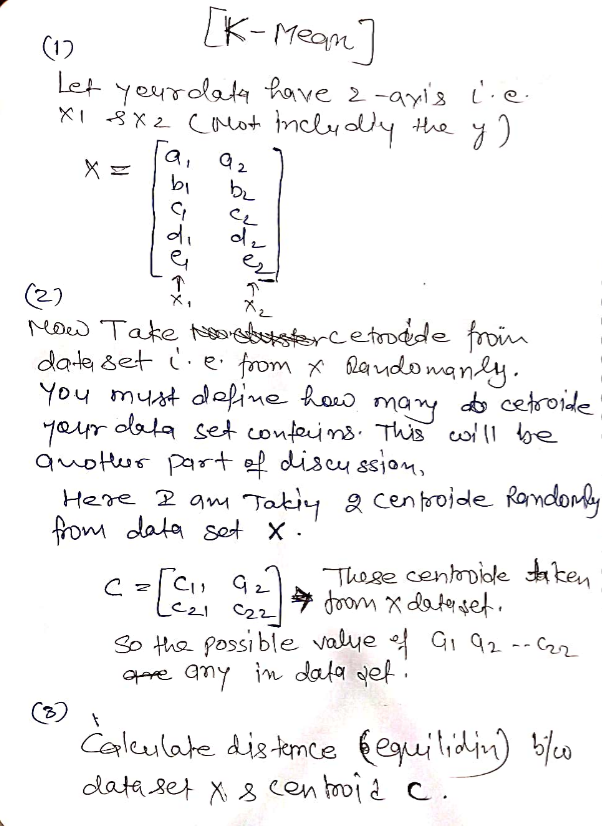

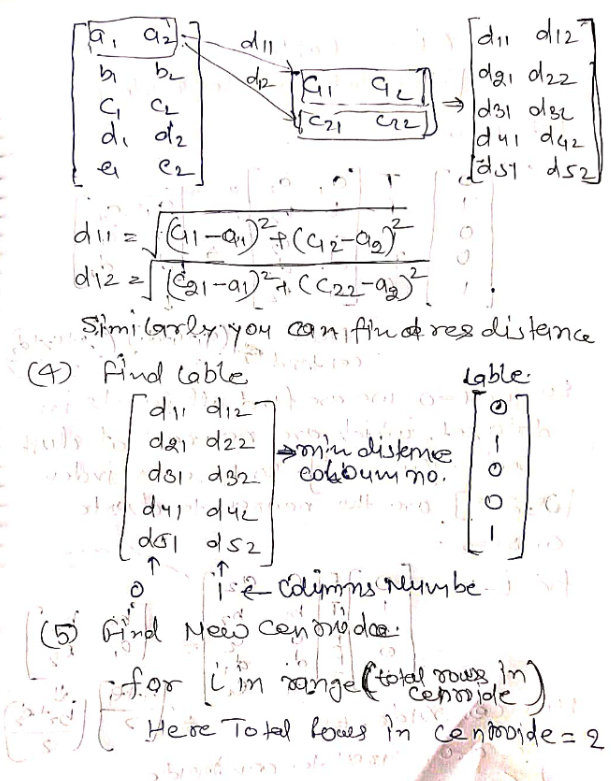

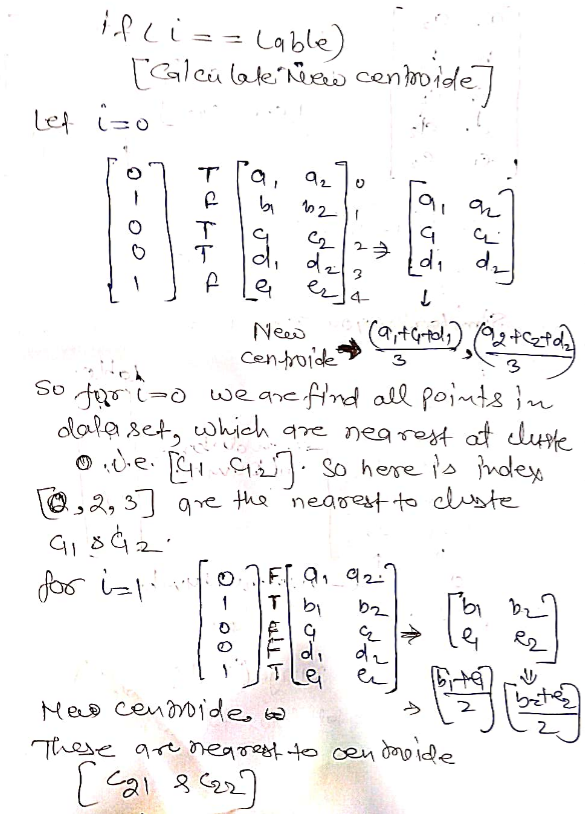

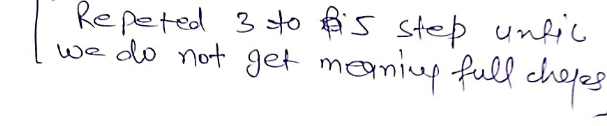

### See below Example Code:


In [126]:
# Get Sample Pont
def get_2d_randint_data(n_samples=100, n_features=2, seed=None, low=0, high=10):    
    if seed is not None:
        np.random.seed(seed)
    return np.random.randint(low, high, size=(n_samples, n_features))
sampl = 10
fx = get_2d_randint_data(n_samples=sampl,n_features = 2, seed=42,low=0, high=20)

In [ ]:
# get randomly selected 2 points from fx
def get_random_points(data, num_points):
    indices = nprnd.choice(data.shape[0], num_points, replace=False)
    return data[indices]

centroide = get_random_points(fx,2)
print("Randomly selected points:\n", centroide)

distances = np.linalg.norm(fx[:, np.newaxis] - centroide, axis=2)
labels = np.argmin(distances, axis=1)
print("Distances:\n", distances)
print("Labels:\n", labels)
print('Select Datapoint nearesr from lable 0:\n',fx[labels == 0])
print('Select Datapoint nearesr from lable 0:\n',fx[labels == 1])

In [129]:
#calculate mean of each centroide
mean_centroide_0 = fx[labels == 0].mean(axis=0)
mean_centroide_1 = fx[labels == 1].mean(axis=0)
print("Mean of centroide 0:", mean_centroide_0)
print("Mean of centroide 1:", mean_centroide_1)

Mean of centroide 0: [ 2.33333333 13.66666667]
Mean of centroide 1: [10.28571429  6.85714286]


### Basice Example of K-Mean (AI genrated code)

In [121]:
# K-Means Algorithm
centroide_lst = []
def kmeans(X, k, max_iters=100):
    n_samples, n_features = X.shape
    # Randomly initialize centroids
    centroids = X[nprnd.choice(n_samples, k, replace=False)]    
    for itr in range(max_iters):
        # Assign clusters based on closest centroid
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)
        
        # Compute new centroids
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        
        # Check for convergen
        # ce
        if np.all(centroids == new_centroids):
            break
        centroide_lst.append(centroids)
        centroids = new_centroids
    
    return labels, centroids, itr


In [122]:
X,y = make_blobs(n_samples = 500,n_features = 2,centers = 3,random_state = 23)
X.shape

(500, 2)

number of iterations: 8


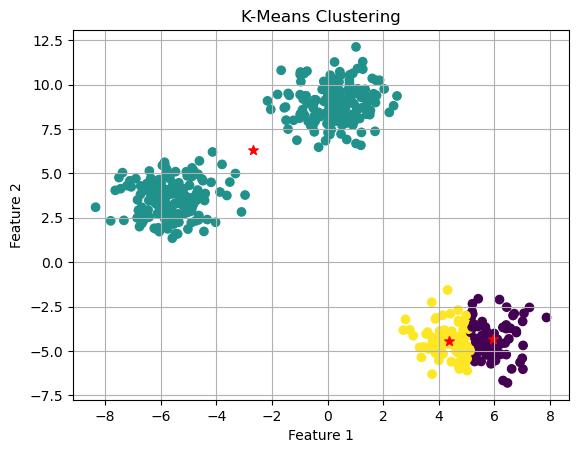

In [123]:
kmeans_labels, centroids,itr = kmeans(X, k=3)
print("number of iterations:", itr)
fig = plt.figure(1)
plt.grid(True)
plt.scatter(X[:,0], X[:,1], c=kmeans_labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], s=50, c='red', marker='*')  # Plot centroids
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()



### ScitKit Lern Method:

kmeans = KMeans(n_clusters=k)

y_pred = kmeans.fit_predict(X)

number of clusters k : Number of cluster dependent upon number of different type of iteams in data set.
                       
                       How to know value of k ?



***Example:***
                
k = 5

kmeans = KMeans(n_clusters=k)

y_pred = kmeans.fit_predict(X)

KMeans instance preserves a copy of the labels of the instances it was trained on, available via the labels_ instance variable.

y_pred is kmeans.labels_    ???

### Centroid Initialization Methods

**Method 1:**
set the init hyperparameter to a NumPy array containing the list of centroids

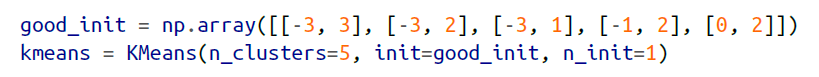

**Method 2:**

Another solution is to **run the algorithm multiple times with different random initializations and keep the best solution**. 

- This is controlled by the n_init hyperparameter:

    by default, it is equal to 10, which means that the whole algorithm described earlier actually runs 10 times when you call fit(), and Scikit-Learn keeps the best solution.

### Qus: How to know which solution is the best?

##### Calculate inertia of Models
Calculate the model’s inertia. mean squared distance between each instance and its closest centroid.

**Note: keeps the model with the lowest inertia**

In scikit lern you can calucate by ***kmeans.inertia_***

##### Calculate score() of the models

**score()** method returns the negative inertia. Why negative? Well, it is because a
predictor’s score() method must always respect the 

***Note: "great is better" rule.***

**k centroids that the algorithm found:**

kmeans.cluster_centers_

### Important improvement to the K-Means algorithm

**Accelerated K-Means:**

It considerably accelerates the algorithm by ***avoiding many unnecessary distance calculations***

Achieved by **exploiting the triangle inequality** (i.e., the **straight line is always the shortest**) and by keeping track of lower and upper bounds for distances between instances and centroids.

The triangle inequality is AC ≤ AB + BC where A, B and C are three points, and AB, AC and BC are the
distances between these points.

**Mini-batch K-Means:**

proposed in a 2010 paper by David Sculley

I**nstead of using the full dataset at each iteration**, the algorithm is capable of **using mini-batches**, moving the centroids just slightly at each iteration.

This speeds up the algorithm typically by a factor of 3 or 4 and makes it possible to cluster huge datasets that do not fit in memory.

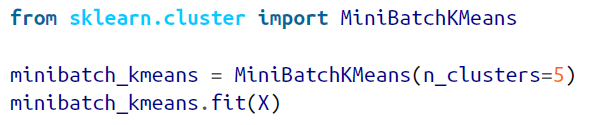

### Finding the Optimal Number of Clusters

##### Qus: Why this impotant?

From data set its very dificult to know how many cluster we required. However to visualized dataset by graph we can assume how many cluster is requred. But Still its not good approch becose the result might be quite bad if you set it to the wrong value.

So your next approch is just pick the model with the lowest inertia, right? Unfortunately, it is not that simple. See how?

The inertia for k=3 is 653.2, which is much higher than for k=5 (which was 211.6), but with k=8, the inertia is just 119.1. (***As we know for this perticular modesl k =5 is best solutions.***).

The inertia is not a good performance metric when trying to choose k since it keeps getting lower as we increase k. Indeed, the more clusters there are, the closer each instance will be to its closest centroid, and therefore the lower the inertia will be.

##### Selecting the number of clusters k using the “elbow rule”

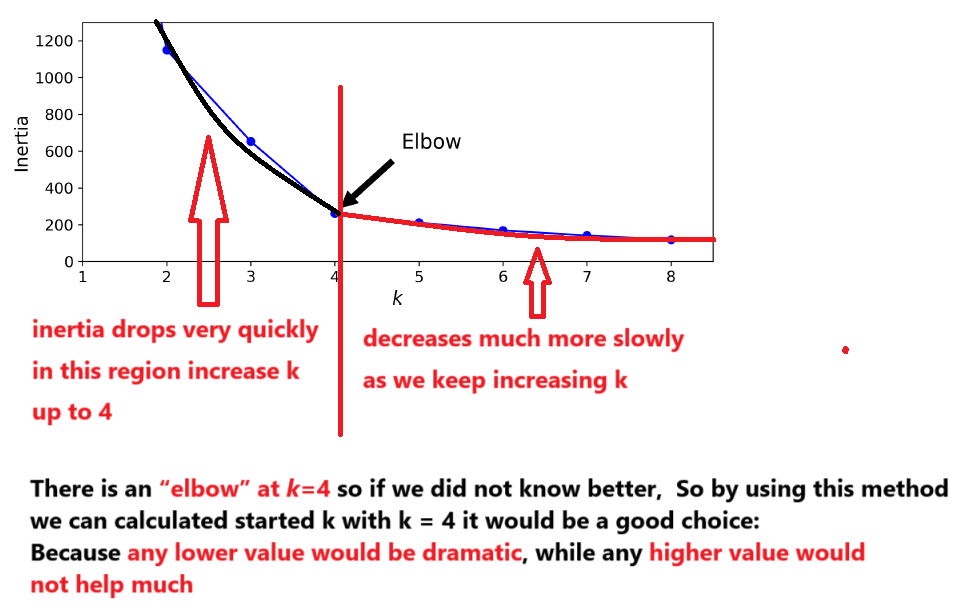

##### Calculate silhouette score

This technique for choosing the best value for the number of clusters but also more computationally expensive.

**silhouette score**, which is the ***mean silhouette coefficient over all the instances***.

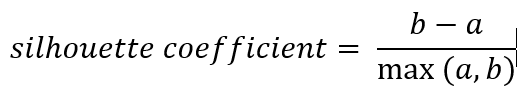

where a is the mean distance to the other instances in the same cluster (it is the mean intra-cluster distance)

b is the mean nearest-cluster distance, that is the mean distance to the instances of the next closest cluster (defined as the one that minimizes b, excluding the instance’s own cluster)

TODO: Math behind silhouette score

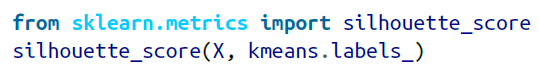

TODO: Plot and analyzed with Selecting the number of clusters k using the silhouette score

TODO: Plot and analyzed with Silouhette analysis: comparing the silhouette diagrams for various values of
k

### Limits of K-Means

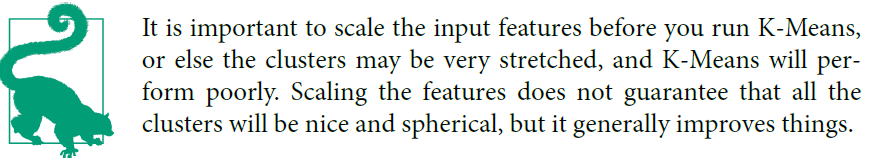


### Example Based on K-Mean

##### Example 1: Using clustering for image segmentation
TODO:

##### Example 2: Using Clustering for Preprocessing
TODO: